<a href="https://colab.research.google.com/github/pemo-studi61/multiportupload-app/blob/main/MultiportUpload_BenchmarkRunEval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistische Auswertung der Benchmarkdaten

Letzte Aktualisierung: **14/07/2026**

Autor: **Peter Monadjemi**

## Einleitung

Dieses Notebook dient der statistischen Auswertung der im Rahmen der Masterarbeit erhobenen Benchmarkdaten der MultiPortUpload-Plattform.

Die Benchmarkdaten wurden unter reproduzierbaren Netzwerkbedingungen mit unterschiedlichen Upload-Adaptern, Dateigrößen und Netzwerkprofilen erhoben. Ziel der Auswertung ist die Beantwortung der Forschungsfragen anhand deskriptiver und inferenzstatistischer Verfahren.

Jeder Benchmark-Lauf basiert auf einem "Fullrun". Das bedeutet konkret, dass alle Personas mit allen Adaptern, 5 Dateigrößen und 4 Wiederholungen getestet wurden, so dass jeder Lauf 800 BenchmarkRecords umfasst.

Der Fullrun erschien zur Beantwortung der drei Forschungsfragen als die beste Alternative.

Da jeder Benchmarklauf unter identischen Bedingungen ausgeführt wurde, sollten sich die Daten nur geringfügig unterscheiden.

Die Auswertung erfolgt in folgenden Schritten:

1. JSON-Datei auswählen und laden
2. Daten validieren
3. Kennzahlen berechnen
4. Deskriptive Statistik
5. Forschungsfrage 1 analysieren und beantworten
6. Forschungsfrage 2 analysieren und beantworten
7. Forschungsfrage 3 analysieren und beantworten
8. Gesamtergebnis zusammenfassen
9. Diagramme, Tabellen und Texte speichern

# 1 - Installieren und Laden der R-Packages

Im ersten Schritt müssen eine Reihe von R-Packages installiert und geladen werden.

In [148]:
# ---------------------------------------------------------
# Pakete installieren und laden
# ---------------------------------------------------------

required_packages <- c(
  "jsonlite",
  "dplyr",
  "tidyr",
  "ggplot2",
  "glue",
  "knitr",
  "IRdisplay",
  "dunn.test"
)

installed <- rownames(installed.packages())

missing <- setdiff(required_packages, installed)

if (length(missing) > 0) {
  install.packages(
    missing,
    repos = "https://cloud.r-project.org"
  )
}

invisible(
  lapply(
    required_packages,
    library,
    character.only = TRUE
  )
)

In [149]:
cat("Pakete:\n")

for (pkg in required_packages) {
  if (pkg %in% installed) {
    cat(sprintf("✓ %s\n", pkg))
  } else {
    cat(sprintf("➜ %s installiert\n", pkg))
  }
}

Pakete:
✓ jsonlite
✓ dplyr
✓ tidyr
✓ ggplot2
✓ glue
✓ knitr
✓ IRdisplay
✓ dunn.test


## 1.1 - Globale Variablen

In [150]:
DATA_DIR   <- "content/data"
OUTPUT_DIR <- "content/output"
FIGURE_DIR <- file.path(OUTPUT_DIR, "figures")
TABLE_DIR  <- file.path(OUTPUT_DIR, "tables")
REPORT_DIR <- file.path(OUTPUT_DIR, "reports")

dir.create(
  REPORT_DIR,
  recursive = TRUE,
  showWarnings = FALSE
)

dir.create(FIGURE_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(TABLE_DIR, recursive = TRUE, showWarnings = FALSE)

adapter_colors <- c(
  "Memory" = "#1f77b4",
  "LocalFile" = "#ff7f0e",
  "Streaming" = "#2ca02c",
  "Chunked" = "#d62728",
  "Resumable" = "#9467bd",
  "QueueBased" = "#8c564b",
  "Hashing" = "#e377c2",
  "VirusScanMock" = "#7f7f7f",
  "S3" = "#bcbd22",
  "S3Presigned" = "#17becf"
)

## 1.2 - SavePlot-Function

Diese Function speichert Bitmaps einheitlich ab.

In [151]:
save_plot <- function(plot, filename, width = 12, height = 7, dpi = 300) {
  ggsave(
    filename = file.path(FIGURE_DIR, filename),
    plot = plot,
    width = width,
    height = height,
    dpi = dpi
  )

  cat(sprintf("✓ Abbildung gespeichert: %s\n",
              file.path(FIGURE_DIR, filename)))
}

### 1.3 format_liste-Funktion

Diese Function soll eine schöne Aufzählung erzeugen.

In [152]:
# ---------------------------------------------------------
# Hilfsfunktion: Schöne Aufzählung erzeugen
# ---------------------------------------------------------

format_liste <- function(x) {

  x <- unique(na.omit(as.character(x)))

  if (length(x) == 0) {
    return("")
  }

  if (length(x) == 1) {
    return(x)
  }

  if (length(x) == 2) {
    return(paste(x, collapse = " und "))
  }

  paste(
    paste(x[-length(x)], collapse = ", "),
    x[length(x)],
    sep = " und "
  )
}

# 2 - Auswahl einer JSON-Datei

Als ersten aktiven Schritt wird eine JSON-Dateien aus dem DATA_DIR-Verzeichnis ausgewählt.

In [185]:
 # ---------------------------------------------------------
# JSON-Datei auswählen und laden
# ---------------------------------------------------------

# Define the list of Google Drive URLs as direct download links
# Provide a descriptive name (e.g., filename without .json) for each URL.
# Example for the first entry provided by the user.
DATA_DIR_urls <- c(
  "BenchmarkRun-0507-26-FullRun-01" = "https://drive.google.com/uc?export=download&id=1D06Bsgjjogq6AfvFaBVbJuv1dkMTyrqA",
  "BenchmarkRun-1107_26-FullRun-01" = "https://drive.google.com/uc?export=download&id=15uQqSa0L9oz9mcu3QDLxbHviqJRAQc56",
  "BenchmarkRun-1207_26-FullRun-01" = "https://drive.google.com/uc?export=download&id=14cJYnM6L0BzkkiOg6QcziQodPx55UJAu",
  "BenchmarkRun-0907-26-FullRun-02" = "https://drive.google.com/uc?export=download&id=1TID5VpiQY89fty2qDJiTDBY2wkFUBOIk",
  "BenchmarkRun-0907-26-FullRun-01" = "https://drive.google.com/uc?export=download&id=1VQJMbgrR7VSJfadR9gb-jEs-pE5nXofof",
  "BenchmarkRun-1007_26-FullRun-01" = "https://drive.google.com/uc?export=download&id=15V6ra3CJoGarMqM548g69ygD-CXTmgTs",
  "BenchmarkRun-0507-26-FullRun-03" = "https://drive.google.com/uc?export=download&id=1-k5UukXZTz9YkRjkfirD2QcTlzLC7xjU",
  "BenchmarkRun-0507_26-FullRun-02" = "https://drive.google.com/uc?export=download&id=1Xn05k-75UYNDFzJ0U5N2bjoPUQNhh1TY",
  "BenchmarkRun-0507-26-FullRun-01" = "https://drive.google.com/uc?export=download&id=1hTD4f4zUyMAJvHBVKBniaCLS-EWQ69pf",
  "BenchmarkRun-0807-26-FullRun-01" = "https://drive.google.com/uc?export=download&id=1PjtHMQ1HvX3UoTQ7r6Ub7vhXd1mRpecl"
)

# The 'json_files' are the URLs (unnamed values of DATA_DIR_urls)
json_files <- unname(DATA_DIR_urls)
# The 'file_descriptions' are the names associated with each URL
file_descriptions <- names(DATA_DIR_urls)

if (length(json_files) == 0) {
  stop("Keine Google Drive JSON-URLs zur Auswahl gefunden.") # Updated error message
}

# Default selection as before
default_index <- 1

# FALSE = automatischer Run-All-Durchlauf
# TRUE  = manuelle Dateiauswahl
interactive_selection <- FALSE

cat("Verfügbare Benchmarkdateien (mit Beschreibung):\n\n") # Updated message

for (i in seq_along(json_files)) {
  cat(sprintf("[%d] %s\n", i, file_descriptions[i])) # Display description
}

cat(sprintf(
  "\nStandard: [%d] %s\n",
  default_index,
  file_descriptions[default_index] # Display description
))

if (interactive_selection && interactive()) {

  selection_input <- readline(
    "\nDatei auswählen (Enter = Standard): "
  )

  if (selection_input == "") {
    selection <- default_index
  } else {
    selection <- suppressWarnings(as.integer(selection_input))

    if (
      is.na(selection) ||
      selection < 1 ||
      selection > length(json_files)
    ) {
      stop("Ungültige Dateiauswahl.")
    }
  }

} else {

  selection <- default_index

  cat(
    "\nAutomatischer Modus: ",
    "Die voreingestellte Datei wird verwendet.\n",
    sep = ""
  )
}

json_file <- json_files[selection] # This is now a URL

cat(sprintf(
  "\nLade '%s' von Google Drive...\n",
  file_descriptions[selection] # Display description for loading
))

# Dynamically update global directories based on selected JSON file description
report_subdir_name <- make.names(file_descriptions[selection]) # Use make.names to create valid directory name

# Re-assign global directory variables with the new subdirectory
REPORT_DIR <<- file.path(OUTPUT_DIR, "reports", report_subdir_name)
FIGURE_DIR <<- file.path(OUTPUT_DIR, "figures", report_subdir_name)
TABLE_DIR  <<- file.path(OUTPUT_DIR, "tables", report_subdir_name)

# Create the new dynamic directories
dir.create(REPORT_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIGURE_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(TABLE_DIR, recursive = TRUE, showWarnings = FALSE)

# jsonlite::fromJSON can directly read from a URL
benchmark <- jsonlite::fromJSON(json_file)
benchmark_df <- benchmark$records

if (!is.data.frame(benchmark_df) || nrow(benchmark_df) == 0) {
  stop("Die JSON-Datei (von Google Drive) enthält keine gültigen BenchmarkRecords.")
}

cat(sprintf(
  "✓ %d BenchmarkRecords geladen.\n",
  nrow(benchmark_df)
))

Verfügbare Benchmarkdateien (mit Beschreibung):

[1] BenchmarkRun-0507-26-FullRun-01
[2] BenchmarkRun-1107_26-FullRun-01
[3] BenchmarkRun-1207_26-FullRun-01
[4] BenchmarkRun-0907-26-FullRun-02
[5] BenchmarkRun-0907-26-FullRun-01
[6] BenchmarkRun-1007_26-FullRun-01
[7] BenchmarkRun-0507-26-FullRun-03
[8] BenchmarkRun-0507_26-FullRun-02
[9] BenchmarkRun-0507-26-FullRun-01
[10] BenchmarkRun-0807-26-FullRun-01

Standard: [1] BenchmarkRun-0507-26-FullRun-01

Automatischer Modus: Die voreingestellte Datei wird verwendet.

Lade 'BenchmarkRun-0507-26-FullRun-01' von Google Drive...
✓ 800 BenchmarkRecords geladen.


## 2.1 - Ausgabe des Titelblatts

Zu Beginn wird ein Titelblatt mit den Eckdaten der geladenen JSON-Datei ausgegeben.

In [186]:
# ---------------------------------------------------------
# Titelblatt
# ---------------------------------------------------------

report_date <- format(Sys.time(), "%d.%m.%Y %H:%M:%S")

# Version des Notebooks
notebook_version <- "1.0.1"

report_title <- glue(
"\n# MultiPortUpload Benchmark Report\n\n---\n\n## Benchmark-Auswertung\n\n| Eigenschaft | Wert |\n|:------------|:-----|\n| **Version** | {notebook_version} |\n| **JSON-Datei** | {file_descriptions[selection]} |\n| **Erstellt am** | {report_date} |\n| **BenchmarkRecords** | {nrow(benchmark_df)} |\n| **Upload-Adapter** | {length(unique(benchmark_df$UploadAdapter))} |\n| **Netzwerkprofile** | {length(unique(benchmark_df$NetworkPreset))} |\n| **Dateigrößen** | {length(unique(benchmark_df$FileSizeCategory))} |\n\n---\n\nDieses Notebook erzeugt einen reproduzierbaren wissenschaftlichen Benchmarkbericht.\n\nDer Bericht umfasst:\n\n- Datenvalidierung\n- Deskriptive Statistik\n- Visualisierung\n- Hypothesentests\n- Forschungsfrage FF1\n- Forschungsfrage FF2\n- Forschungsfrage FF3\n- Entscheidungsmatrix\n- Executive Summary\n\n---\n"
)

IRdisplay::display_markdown(report_title)

# MultiPortUpload Benchmark Report

---

## Benchmark-Auswertung

| Eigenschaft | Wert |
|:------------|:-----|
| **Version** | 1.0.1 |
| **JSON-Datei** | BenchmarkRun-0507-26-FullRun-01 |
| **Erstellt am** | 14.07.2026 13:22:07 |
| **BenchmarkRecords** | 800 |
| **Upload-Adapter** | 10 |
| **Netzwerkprofile** | 4 |
| **Dateigrößen** | 0 |

---

Dieses Notebook erzeugt einen reproduzierbaren wissenschaftlichen Benchmarkbericht.

Der Bericht umfasst:

- Datenvalidierung
- Deskriptive Statistik
- Visualisierung
- Hypothesentests
- Forschungsfrage FF1
- Forschungsfrage FF2
- Forschungsfrage FF3
- Entscheidungsmatrix
- Executive Summary

---

## 2.1 - Ergänzen von Kennzahlen als Spalten

Mit `FileSizeMB` und `ThroughputMBs` werden zwei künstliche Kennzahlen hinzugefügt.

In [155]:
# Dateigröße in MB
benchmark_df <- benchmark_df %>%
  mutate(
    FileSizeMB = FileSizeBytes / (1024 * 1024),

    # Durchsatz in MB/s
    ThroughputMBs = FileSizeMB / (DurationMs / 1000),

    # Dateigrößenkategorie für FF3
    FileSizeCategory = factor(
      case_when(
        FileSizeBytes == 1  * 1024^2 ~ "1 MB",
        FileSizeBytes == 5  * 1024^2 ~ "5 MB",
        FileSizeBytes == 10 * 1024^2 ~ "10 MB",
        FileSizeBytes == 50 * 1024^2 ~ "50 MB",
        TRUE                         ~ "Sonstige"
      ),
      levels = c("1 MB", "5 MB", "10 MB", "50 MB", "Sonstige")
    )
  )

## 2.2 - Datenvalidierung

Vor der statistischen Auswertung wird die Datenqualität überprüft. Dabei werden Anzahl der Datensätze, Variablen, Datentypen, fehlende Werte sowie die Verteilung der Messungen auf Adapter, Netzwerkprofile und Dateigrößen kontrolliert.

In [156]:
cat("=====================================\n")
cat("Datenvalidierung\n")
cat("=====================================\n\n")

cat(sprintf("BenchmarkRecords : %d\n", nrow(df)))
cat(sprintf("Variablen        : %d\n\n", ncol(df)))

cat("Spalten:\n")
print(names(df))

cat("\nDatentypen:\n")
str(benchmark_df)

cat("\nFehlende Werte pro Spalte:\n")
print(colSums(is.na(benchmark_df)))

cat("\nErfolgreiche Uploads:\n")
print(table(benchmark_df$Success))

cat("\nUpload-Adapter:\n")
print(table(benchmark_df$UploadAdapter))

cat("\nNetzwerkprofile:\n")
print(table(benchmark_df$NetworkPreset))

cat("\nDateigrößen:\n")
print(table(benchmark_df$FileSizeBytes))

Datenvalidierung

Spalten:
NULL

Datentypen:
'data.frame':	800 obs. of  24 variables:
 $ benchmark_run_uuid: chr  "a2bf3df60d42489491882772f6423f57" "a2bf3df60d42489491882772f6423f57" "a2bf3df60d42489491882772f6423f57" "a2bf3df60d42489491882772f6423f57" ...
 $ RunIndex          : int  1 1 1 1 1 1 1 1 1 1 ...
 $ UploadAdapter     : chr  "LocalFile" "LocalFile" "LocalFile" "LocalFile" ...
 $ FileName          : chr  "sample-1mb.bin" "sample-1mb.bin" "sample-1mb.bin" "sample-1mb.bin" ...
 $ FileSizeBytes     : int  1048576 1048576 1048576 1048576 1048576 5242880 5242880 5242880 5242880 5242880 ...
 $ DurationMs        : num  11145 5706 5147 4576 5122 ...
 $ Success           : logi  TRUE TRUE TRUE TRUE TRUE TRUE ...
 $ ArtifactId        : chr  "cd160dcc99d24a9392737b4b6a0ae941" "1dd53a0d5aa34d8bbd7eedd37bb0832d" "159f2fe3bd584713b1e5b24d58a5b017" "40c0879657364359a2cf0370f3b1ce6a" ...
 $ StoredFileName    : chr  "cd160dcc99d24a9392737b4b6a0ae941_sample-1mb.bin" "1dd53a0d5aa34d8bbd7eedd37b

# 3 - Deskriptive Statistik

Nach der Datenvalidierung werden die Benchmarkdaten zunächst deskriptiv ausgewertet.

Die deskriptive Statistik dient der Beschreibung der erhobenen Benchmarkdaten. Sie liefert einen Überblick über die Verteilung der Messwerte, ohne bereits statistische Hypothesen zu prüfen.

Da die Forschungsfragen hauptsächlich den Vergleich der Upload-Adapter hinsichtlich ihrer Übertragungsleistung betreffen, wird der Durchsatz (MB/s) als primäre Zielgröße betrachtet. Ergänzend wird die Upload-Dauer (ms) ausgewertet.

## 3.1 - Übersicht über die Kennzahlen

Für jeden Upload-Adapter werden folgende Kennzahlen berechnet:

- Anzahl der Messungen (n)
- Mittelwert
- Median
- Standardabweichung
- Minimum
- 1. Quartil (Q1)
- 3. Quartil (Q3)
- Maximum
- Interquartilsabstand (IQR)
- Erfolgsquote

### Erklärung zu einzelnen Kennzahlen
- n zeigt, dass alle Adapter mit derselben Anzahl an Messungen verglichen wurden.
- Median ist bei Benchmarkdaten oft aussagekräftiger als der Mittelwert, da einzelne Ausreißer den Mittelwert beeinflussen können.
- Die Standardabweichung beschreibt die Streuung der Messwerte und gibt Hinweise auf die Stabilität eines Adapters.
- Q1, Q3 und IQR beschreiben die Verteilung der mittleren 50 % der Messwerte und sind robust gegenüber Ausreißern.
- Die Erfolgsquote ergänzt die reine Performance um die Zuverlässigkeit des Adapters.

### Gesamtdurchsatz mit allen Adaptern

In [157]:
cat("=====================================\n")
cat("Deskriptive Statistik\n")
cat("=====================================\n\n")

summary(benchmark_df[, c(
  "DurationMs",
  "ThroughputMBs",
  "FileSizeMB"
)])

Deskriptive Statistik



   DurationMs     ThroughputMBs       FileSizeMB  
 Min.   :   736   Min.   :0.08973   Min.   : 1.0  
 1st Qu.:  6572   1st Qu.:0.15267   1st Qu.: 4.0  
 Median : 32108   Median :0.19724   Median : 7.5  
 Mean   : 79475   Mean   :0.33781   Mean   :16.5  
 3rd Qu.: 70916   3rd Qu.:0.40000   3rd Qu.:20.0  
 Max.   :362570   Max.   :1.69945   Max.   :50.0  

### Medianwert pro Adapter

Da die Uploaddaten nicht normalverteilt sind und Ausreißer enthalten können, stellt der Median die robustere Kennzahl zur Beschreibung der zentralen Tendenz dar. Der Mittelwert wird ergänzend angegeben, um die Ergebnisse vollständig zu dokumentieren.

In [158]:
deskriptiv_adapter <- benchmark_df %>%
  group_by(UploadAdapter) %>%
  summarise(
    n = n(),

    Median_MBps = median(ThroughputMBs),
    Mittelwert_MBps = mean(ThroughputMBs),
    SD_MBps = sd(ThroughputMBs),

    Median_ms = median(DurationMs),
    Mittelwert_ms = mean(DurationMs),
    SD_ms = sd(DurationMs),

    Erfolgsquote = mean(Success) * 100
  ) %>%
  mutate(across(where(is.numeric), ~ round(.x, 2)))

knitr::kable(deskriptiv_adapter)



|UploadAdapter |  n| Median_MBps| Mittelwert_MBps| SD_MBps| Median_ms| Mittelwert_ms|     SD_ms| Erfolgsquote|
|:-------------|--:|-----------:|---------------:|-------:|---------:|-------------:|---------:|------------:|
|Chunked       | 80|        0.22|            0.35|    0.25|  25424.18|      64136.76|  84896.93|          100|
|Hashing       | 80|        0.18|            0.34|    0.30|  34754.94|      84130.67| 116837.54|          100|
|LocalFile     | 80|        0.19|            0.33|    0.28|  32969.15|      83688.10| 116672.75|          100|
|Memory        | 80|        0.19|            0.36|    0.34|  34250.69|      82832.61| 115107.35|          100|
|QueueBased    | 80|        0.18|            0.33|    0.29|  34101.85|      84268.47| 117163.25|          100|
|Resumable     | 80|        0.23|            0.34|    0.24|  30041.96|      64271.83|  84159.53|          100|
|S3            | 80|        0.19|            0.32|    0.27|  31233.16|      82640.54| 115877.31|          100|

### Median-Durchsatz je Upload-Adapter

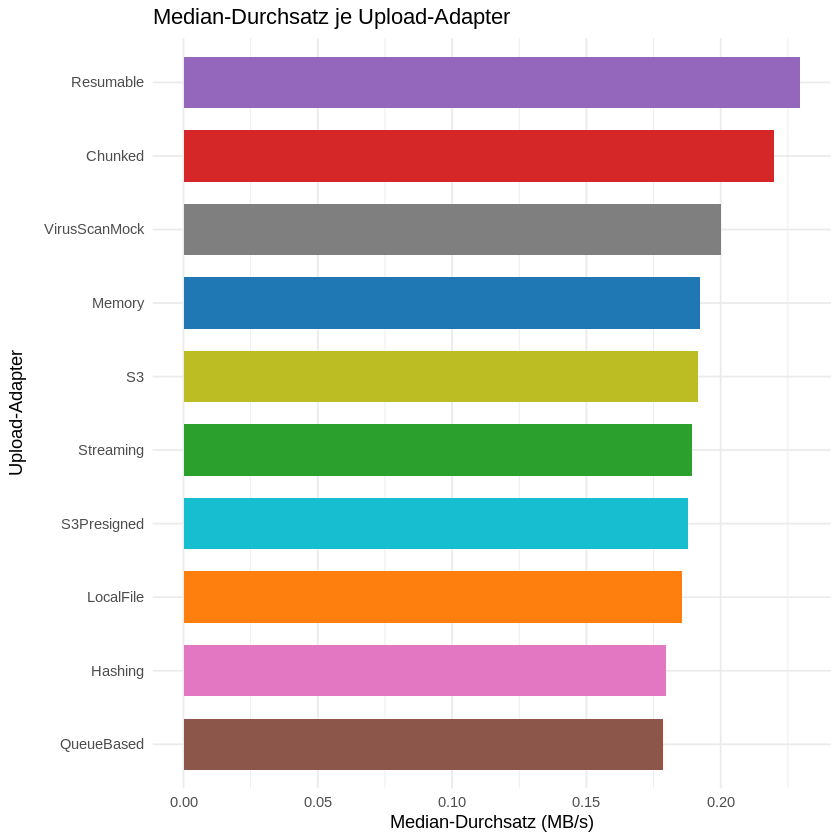

In [159]:
# ---------------------------------------------------------
# Median-Durchsatz je Upload-Adapter
# ---------------------------------------------------------

median_df <- benchmark_df |>
  dplyr::group_by(UploadAdapter) |>
  dplyr::summarise(
    Median_MBps = median(ThroughputMBs, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::arrange(dplyr::desc(Median_MBps))

plot_median <- ggplot(
  median_df,
  aes(
    x = reorder(UploadAdapter, Median_MBps),
    y = Median_MBps,
    fill = UploadAdapter
  )
) +
  geom_col(width = 0.7) +
  coord_flip() +
  scale_fill_manual(values = adapter_colors) +
  labs(
    title = "Median-Durchsatz je Upload-Adapter",
    x = "Upload-Adapter",
    y = "Median-Durchsatz (MB/s)"
  ) +
  theme_minimal() +
  theme(
    legend.position = "none"
  )

plot_median

### Boxplots für Durchsatz und Dauer nach Upload

Zur grafischen Darstellung der Verteilung des Durchsatzes wird zunächst ein Boxplot erstellt.

Der Boxplot visualisiert die Lage und Streuung der Messwerte für jeden Upload-Adapter. Dargestellt werden Median, Quartile, Interquartilsabstand sowie potenzielle Ausreißer.

Er dient der explorativen Analyse der Benchmarkdaten. Er zeigt die Verteilung des Durchsatzes je Upload-Adapter und visualisiert Median, Quartile, Interquartilsabstand sowie Ausreißer. Die Darstellung unterstützt die Interpretation der späteren Ergebnisse des Kruskal-Wallis-Tests.

Da der Kruskal-Wallis-Test auf den Rängen der Messwerte basiert, eignet sich der Boxplot besonders gut zur Vorbereitung und Interpretation der statistischen Analyse.

In [187]:
# Feste Farben für alle Upload-Adapter

plot_box <- ggplot(
  benchmark_df,
  aes(
    x = reorder(UploadAdapter, ThroughputMBs, median),
    y = ThroughputMBs,
    fill = UploadAdapter
  )
) +
  geom_boxplot(outlier.colour = "red",
               outlier.size = 2) +
  scale_fill_manual(values = adapter_colors) +
  labs(
    title = "Durchsatz nach Upload-Adapter",
    subtitle = "Verteilung aller BenchmarkRecords",
    x = "Upload-Adapter",
    y = "Durchsatz (MB/s)"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

plot_box

save_plot(plot_box, "01-boxplot_throughput_by_adapter.png")

cat("✓ Abbildung gespeichert unter:\n")
cat(file.path(FIGURE_DIR, "01-boxplot_throughput_by_adapter.png"), "\n")

ERROR while rich displaying an object: Error in `geom_boxplot()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'ThroughputMBs' not found

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(

ERROR: [1m[33mError[39m in `geom_boxplot()`:[22m
[1m[22m[33m![39m Problem while computing aesthetics.
[36mℹ[39m Error occurred in the 1st layer.
[1mCaused by error:[22m
[33m![39m object 'ThroughputMBs' not found


# 4 Statistische Hypothesen

Zur statistischen Überprüfung der Leistungsunterschiede zwischen den Upload-Adaptern werden folgende Hypothesen formuliert:

**Nullhypothese (H₀):**

Die Verteilung des Durchsatzes unterscheidet sich zwischen den Upload-Adaptern nicht.

**Alternativhypothese (H₁):**

Mindestens ein Upload-Adapter weist eine andere Verteilung des Durchsatzes auf.

## 4.1 - Auswahl des statistischen Testverfahrens

Die Verteilung des Durchsatzes wird mithilfe eines Histogramms untersucht. Da keine Normalverteilung vorliegt, wird zur Überprüfung der Hypothesen der nichtparametrische Kruskal-Wallis-Test verwendet.

Das Histogramm zeigt eine deutlich schiefe Verteilung mit Ausreißern und weicht sichtbar von einer Normalverteilung ab. Die Voraussetzung einer Normalverteilung ist somit nicht erfüllt.

Aus diesem Grund wird im weiteren Verlauf der Auswertung ein **nichtparametrischer Kruskal-Wallis-Test** verwendet, der keine Normalverteilung der Daten voraussetzt.

✓ Abbildung gespeichert: content/output/figures/02-histogram_throughput.png
✓ Abbildung gespeichert unter:
../output/figures/02-histogram_throughput.png


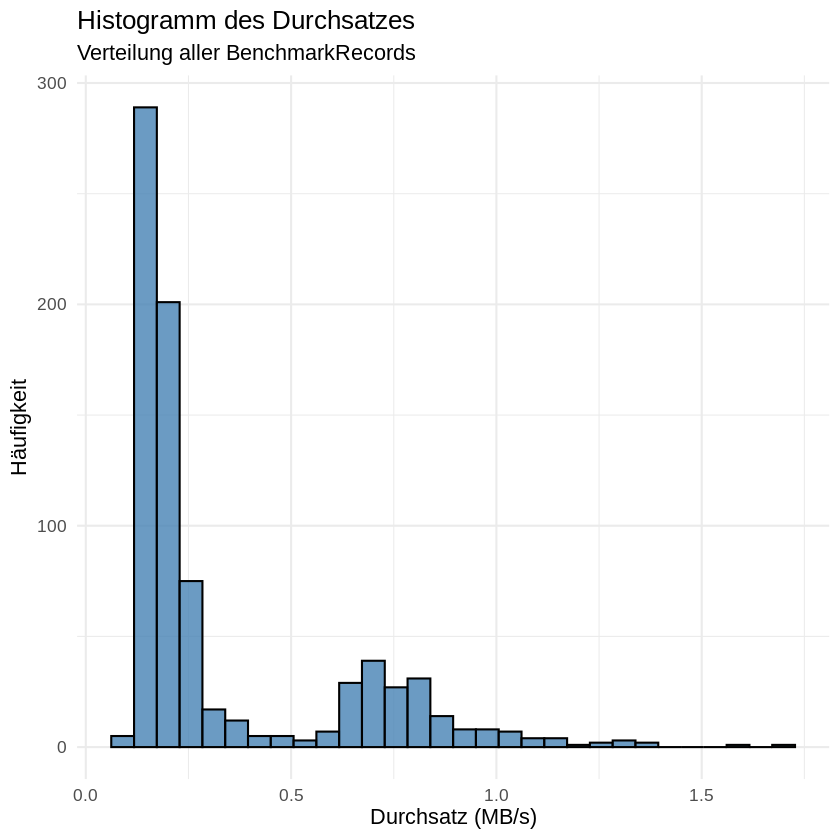

In [161]:
plot_histogram <- ggplot(
  benchmark_df,
  aes(x = ThroughputMBs)
) +
  geom_histogram(
    bins = 30,
    fill = "steelblue",
    color = "black",
    alpha = 0.8
  ) +
  labs(
    title = "Histogramm des Durchsatzes",
    subtitle = "Verteilung aller BenchmarkRecords",
    x = "Durchsatz (MB/s)",
    y = "Häufigkeit"
  ) +
  theme_minimal(base_size = 13)

plot_histogram

save_plot(
  plot_histogram, "02-histogram_throughput.png"
)

cat("✓ Abbildung gespeichert unter:\n")
cat("../output/figures/02-histogram_throughput.png\n")

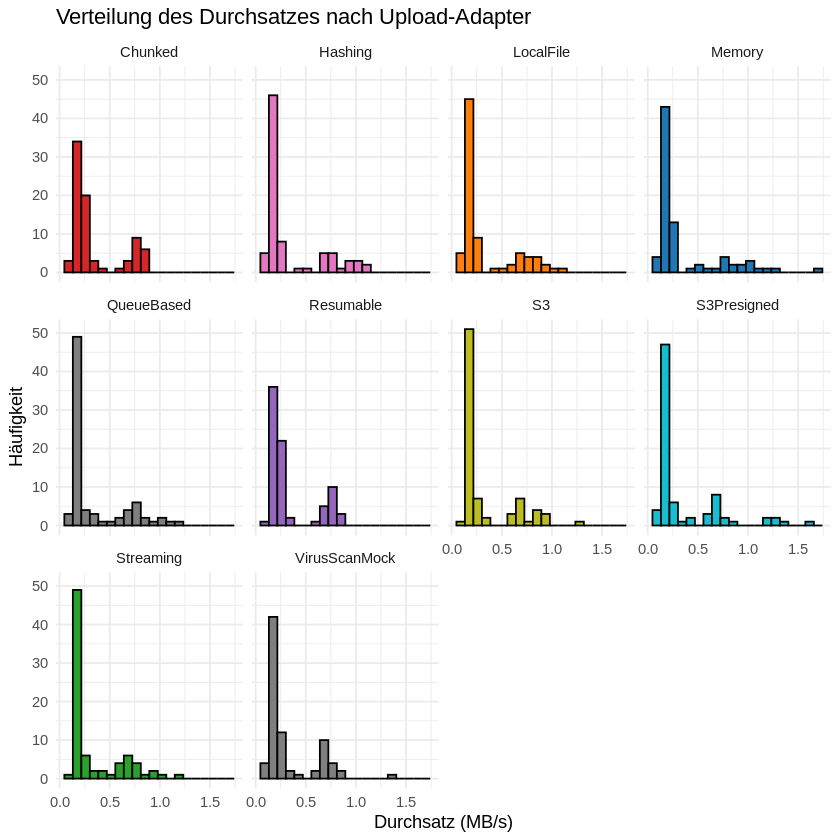

In [162]:
plot_histogram_adapter <- ggplot(
  benchmark_df,
  aes(
    x = ThroughputMBs,
    fill = UploadAdapter
  )
) +
  geom_histogram(
    bins = 20,
    color = "black"
  ) +
  scale_fill_manual(values = adapter_colors) +
  facet_wrap(~ UploadAdapter) +
  theme_minimal() +
  theme(
    legend.position = "none"
  ) +
  labs(
    title = "Verteilung des Durchsatzes nach Upload-Adapter",
    x = "Durchsatz (MB/s)",
    y = "Häufigkeit"
  )

plot_histogram_adapter

# 5 - Beantwortung der Forschungsfragen

In diesem Abschnitt werden die drei Forschungsfragen beantwortet. Die Antworten werden direkt aus den Messdaten extrahiert und dynamisch zusammengestellt, so dass sie vom gewählten Testdatensatz abhängen.

## 5.1 - Forschungsfrage 1 (FF1)

**Welcher Upload-Adapter erzielt unter identischen Netzwerkbedingungen den höchsten Durchsatz?**

### FF1 - Unterschiede im Durchsatz zwischen den Upload-Adaptern berechnen

In [163]:
# ---------------------------------------------------------
# Forschungsfrage FF1:
# Unterschiede im Durchsatz zwischen den Upload-Adaptern
# ---------------------------------------------------------

alpha <- 0.05

# 1. Deskriptives Ranking nach Median-Durchsatz
ff1_ranking <- benchmark_df |>
  dplyr::group_by(UploadAdapter) |>
  dplyr::summarise(
    Anzahl = dplyr::n(),
    Median_MBps = median(ThroughputMBs, na.rm = TRUE),
    Mittelwert_MBps = mean(ThroughputMBs, na.rm = TRUE),
    IQR_MBps = IQR(ThroughputMBs, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::arrange(dplyr::desc(Median_MBps))

# 2. Kruskal-Wallis-Test durchführen
kruskal_result <- kruskal.test(
  ThroughputMBs ~ UploadAdapter,
  data = benchmark_df
)

# 3. Ergebnisse auslesen
kw_h <- unname(kruskal_result$statistic)
kw_df <- unname(kruskal_result$parameter)
kw_p <- kruskal_result$p.value

# 4. Ranking ausgeben
knitr::kable(
  ff1_ranking,
  digits = 4,
  caption = "Ranking der Upload-Adapter nach Median-Durchsatz"
)

# 5. Testergebnis formatiert ausgeben
cat("\nKruskal-Wallis-Test\n")
cat(sprintf("Chi-Quadrat = %.4f\n", kw_h))
cat(sprintf("Freiheitsgrade = %d\n", kw_df))
cat(sprintf("p-Wert = %.6f\n", kw_p))



Table: Ranking der Upload-Adapter nach Median-Durchsatz

|UploadAdapter | Anzahl| Median_MBps| Mittelwert_MBps| IQR_MBps|
|:-------------|------:|-----------:|---------------:|--------:|
|Resumable     |     80|      0.2295|          0.3423|   0.1243|
|Chunked       |     80|      0.2199|          0.3464|   0.1839|
|VirusScanMock |     80|      0.2002|          0.3210|   0.2039|
|Memory        |     80|      0.1922|          0.3559|   0.1738|
|S3            |     80|      0.1916|          0.3248|   0.1538|
|Streaming     |     80|      0.1893|          0.3234|   0.2686|
|S3Presigned   |     80|      0.1878|          0.3617|   0.3267|
|LocalFile     |     80|      0.1855|          0.3295|   0.2784|
|Hashing       |     80|      0.1796|          0.3396|   0.2663|
|QueueBased    |     80|      0.1783|          0.3335|   0.2673|


Kruskal-Wallis-Test
Chi-Quadrat = 28.6997
Freiheitsgrade = 9
p-Wert = 0.000728


### FF1 - Wenn Kruskal-Wallis eine Signifikanz ergibt, Dunn-Test ausführen

In [164]:
if (kruskal_result$p.value < alpha) {

  dunn_result <- dunn.test::dunn.test(
    x = benchmark_df$ThroughputMBs,
    g = benchmark_df$UploadAdapter,
    method = "bonferroni"
  )

  # Check if comparison results are valid before constructing dunn_table
  if (length(dunn_result$comparisons) > 0 &&
      length(dunn_result$statistics) > 0 &&
      length(dunn_result$P.adjusted) > 0) { # Corrected to P.adjusted

    # Manually construct dunn_table from dunn.test output
    dunn_table <- data.frame(
      Comparison = dunn_result$comparisons,
      Z = dunn_result$statistics,
      P.adj = dunn_result$P.adjusted # Corrected to P.adjusted
    ) |>
      dplyr::mutate(
        Signifikant = ifelse(P.adj < alpha, "Ja", "Nein")
      ) |>
      dplyr::arrange(P.adj)

    knitr::kable(
      dunn_table,
      digits = 4,
      caption = "Dunn-Post-hoc-Test mit Bonferroni-Korrektur"
    )

  } else {
    # If no valid comparisons, create an empty data frame
    dunn_table <- data.frame(
      Comparison = character(),
      Z = numeric(),
      P.adj = numeric(),
      Signifikant = character()
    )
    cat("Hinweis: Dunn-Test konnte keine gültigen Vergleichsdaten erzeugen.\n")
  }

} else {

  dunn_result <- NULL
  dunn_table <- NULL

  cat(
    "\nDer Kruskal-Wallis-Test ist nicht signifikant.",
    "Ein Post-hoc-Test wird daher nicht durchgeführt.\n"
  )
}

  Kruskal-Wallis rank sum test

data: x and group
Kruskal-Wallis chi-squared = 28.6997, df = 9, p-value = 0


                    Dunn's Pairwise Comparison of x by group                    
                                  (Bonferroni)                                  

Col Mean-│
Row Mean │    Chunked    Hashing   LocalFil     Memory   QueueBas   Resumabl
─────────┼──────────────────────────────────────────────────────────────────
 Hashing │   3.184728
         │     0.0326 
         │
LocalFil │   2.951749  -0.232979
         │     0.0711     1.0000 
         │
  Memory │   2.481002  -0.703726  -0.470747
         │     0.2948     1.0000     1.0000 
         │
QueueBas │   3.337995   0.153267   0.386245   0.856993
         │     0.0190*    1.0000     1.0000     1.0000 
         │
Resumabl │  -0.089976  -3.274704  -3.041725  -2.570978  -3.427970
         │     1.0000     0.0238*    0.0529     0.2282     0.0137*
         │
      S3 │   2.508371  -0.676357  -0.443378   0.027369  -0.829

Hinweis: Dunn-Test konnte keine gültigen Vergleichsdaten erzeugen.


### FF1 - Automatische Beantwortung der Forschungsfrage

In [165]:
bester_adapter <- ff1_ranking$UploadAdapter[1]
bester_median <- ff1_ranking$Median_MBps[1]

zweiter_adapter <- ff1_ranking$UploadAdapter[2]
zweiter_median <- ff1_ranking$Median_MBps[2]

if (kw_p < alpha) {

  signifikante_vergleiche <- dunn_table |>
    dplyr::filter(P.adj < alpha)

  anzahl_signifikant <- nrow(signifikante_vergleiche)

  if (anzahl_signifikant > 0) {
    vergleichstext <- paste(
      signifikante_vergleiche$Comparison,
      collapse = ", "
    )
  } else {
    vergleichstext <- "keine einzelnen Adapterpaare"
  }

  hypothesentext <- paste0(
    "Der Kruskal-Wallis-Test ergab statistisch signifikante ",
    "Unterschiede zwischen den Upload-Adaptern. ",
    "Die Nullhypothese wird verworfen."
  )

} else {

  anzahl_signifikant <- 0
  vergleichstext <- "keine, da kein Post-hoc-Test durchgeführt wurde"

  hypothesentext <- paste0(
    "Der Kruskal-Wallis-Test ergab keine statistisch signifikanten ",
    "Unterschiede. Die Nullhypothese kann nicht verworfen werden."
  )
}

### FF1 - Signifikante Vergleiche mit dem besten Adapter bestimmen

In [166]:
# Signifikante Vergleiche mit dem besten Adapter bestimmen
signifikante_gegner <- signifikante_vergleiche |>
  dplyr::filter(grepl(bester_adapter, Comparison, fixed = TRUE)) |>
  dplyr::pull(Comparison) |>
  strsplit(" - ", fixed = TRUE) |>
  unlist() |>
  unique()

signifikante_gegner <- signifikante_gegner[
  signifikante_gegner != bester_adapter
]

# Datenabhängiger Dunn-Text
if (anzahl_signifikant == 0) {

  dunn_text <- paste0(
    "Der Dunn-Post-hoc-Test mit Bonferroni-Korrektur zeigte ",
    "keine signifikanten Unterschiede zwischen einzelnen Adapterpaaren."
  )

} else if (anzahl_signifikant == 1) {

  dunn_text <- glue::glue(
    "Der Dunn-Post-hoc-Test mit Bonferroni-Korrektur identifizierte ",
    "einen signifikanten Paarvergleich: {vergleichstext}."
  )

} else {

  dunn_text <- glue::glue(
    "Der Dunn-Post-hoc-Test mit Bonferroni-Korrektur identifizierte ",
    "{anzahl_signifikant} signifikante Paarvergleiche: {vergleichstext}."
  )
}

# Datenabhängige Schlussfolgerung
if (kw_p >= alpha) {

  schluss_text <- glue::glue(
    "Obwohl {bester_adapter} den höchsten Median-Durchsatz erzielte, ",
    "konnten insgesamt keine statistisch signifikanten Unterschiede ",
    "zwischen den Upload-Adaptern nachgewiesen werden."
  )

} else if (length(signifikante_gegner) == 0) {

  schluss_text <- glue::glue(
    "{bester_adapter} erzielte den höchsten Median-Durchsatz und ist ",
    "damit deskriptiv der leistungsstärkste Adapter. Der globale Test ",
    "zeigte zwar signifikante Unterschiede, eine statistisch abgesicherte ",
    "Überlegenheit von {bester_adapter} gegenüber einem konkreten Adapter ",
    "konnte jedoch nicht nachgewiesen werden."
  )

} else {

 if (length(signifikante_gegner) == 1) {

    gegner_text <- signifikante_gegner

  } else {

    gegner_text <- paste(
      paste(signifikante_gegner[-length(signifikante_gegner)], collapse = ", "),
      signifikante_gegner[length(signifikante_gegner)],
      sep = " und "
  )
}
  schluss_text <- glue::glue(
    "{bester_adapter} erzielte den höchsten Median-Durchsatz und ist ",
    "damit deskriptiv der leistungsstärkste Adapter. Eine statistisch ",
    "signifikante Überlegenheit konnte gegenüber {gegner_text} ",
    "nachgewiesen werden. Gegenüber den übrigen Adaptern ergab der ",
    "Dunn-Test keinen signifikanten Unterschied."
  )
}

### FF1 - Automatische Antwort generieren

In [188]:
ff1_text <- glue::glue(
"\n# Beantwortung der Forschungsfrage FF1\n\nDer Adapter **{bester_adapter}** erzielte mit einem Median von\n**{format(round(bester_median, 2), decimal.mark = ',')} MB/s**\nden höchsten Durchsatz. Den zweithöchsten Median erreichte\n**{zweiter_adapter}** mit\n**{format(round(zweiter_median, 2), decimal.mark = ',')} MB/s**.\n\nDer Kruskal-Wallis-Test ergab\n**χ²({kw_df}) = {format(round(kw_h, 4), decimal.mark = ',')}**\nbei einem p-Wert von\n**{format(kw_p, scientific = TRUE, digits = 4)}**.\n\n{hypothesentext}\n\n{dunn_text}\n\n## Antwort auf FF1\n\n{schluss_text}\n"
)

IRdisplay::display_markdown(ff1_text)

# FF1-Bericht in Markdown-Datei speichern
writeLines(
  ff1_text,
  file.path(REPORT_DIR, "ff1.md")
)

# Beantwortung der Forschungsfrage FF1

Der Adapter **Resumable** erzielte mit einem Median von
**0,23 MB/s**
den höchsten Durchsatz. Den zweithöchsten Median erreichte
**Chunked** mit
**0,22 MB/s**.

Der Kruskal-Wallis-Test ergab
**χ²(9) = 28,6997**
bei einem p-Wert von
**7.281e-04**.

Der Kruskal-Wallis-Test ergab statistisch signifikante Unterschiede zwischen den Upload-Adaptern. Die Nullhypothese wird verworfen.

Der Dunn-Post-hoc-Test mit Bonferroni-Korrektur zeigte keine signifikanten Unterschiede zwischen einzelnen Adapterpaaren.

## Antwort auf FF1

Resumable erzielte den höchsten Median-Durchsatz und ist damit deskriptiv der leistungsstärkste Adapter. Der globale Test zeigte zwar signifikante Unterschiede, eine statistisch abgesicherte Überlegenheit von Resumable gegenüber einem konkreten Adapter konnte jedoch nicht nachgewiesen werden.

## 5.2 - Forschungsfrage FF2

**FF2:** In welchem Ausmaß beeinflusst die Netzwerkdegradation die Performance der einzelnen Upload-Strategien im Vergleich zur stabilen Referenzumgebung?

Für FF2 sollte das Notebook daher je Adapter und Netzwerkprofil berechnen:

- Median-Durchsatz
- Baseline-Median
- absolute Differenz zur Baseline
- prozentuale Veränderung zur Baseline
- optional zusätzlich Dauerzunahme

Die zentrale Kennzahl ist damit

```
Performanceverlust_% = (Baseline_Median - Profil_Median) / Baseline_Median * 100
```


### FF2 - Deskriptive Auswertung

Robustheit unter unterschiedlichen Netzwerkbedingungen

In [168]:
# ---------------------------------------------------------
# Forschungsfrage FF2:
# Einfluss der Netzwerkdegradation gegenüber Baseline
# ---------------------------------------------------------

ff2_summary <- benchmark_df |>
  dplyr::group_by(UploadAdapter, NetworkPreset) |>
  dplyr::summarise(
    Anzahl = dplyr::n(),
    Median_MBps = median(ThroughputMBs, na.rm = TRUE),
    Mittelwert_MBps = mean(ThroughputMBs, na.rm = TRUE),
    IQR_MBps = IQR(ThroughputMBs, na.rm = TRUE),
    .groups = "drop"
  )

baseline_values <- ff2_summary |>
  dplyr::filter(NetworkPreset == "Baseline") |>
  dplyr::select(
    UploadAdapter,
    Baseline_Median_MBps = Median_MBps
  )

ff2_degradation <- ff2_summary |>
  dplyr::left_join(
    baseline_values,
    by = "UploadAdapter"
  ) |>
  dplyr::mutate(
    Absolute_Aenderung_MBps =
      Median_MBps - Baseline_Median_MBps,

    Veraenderung_Prozent =
      (Median_MBps - Baseline_Median_MBps) /
      Baseline_Median_MBps * 100,

    Performanceverlust_Prozent =
      (Baseline_Median_MBps - Median_MBps) /
      Baseline_Median_MBps * 100
  ) |>
  dplyr::arrange(
    UploadAdapter,
    Performanceverlust_Prozent
  )

knitr::kable(
  ff2_degradation,
  digits = 4,
  caption = "Performanceänderung gegenüber der Baseline"
)



Table: Performanceänderung gegenüber der Baseline

|UploadAdapter |NetworkPreset | Anzahl| Median_MBps| Mittelwert_MBps| IQR_MBps| Baseline_Median_MBps| Absolute_Aenderung_MBps| Veraenderung_Prozent| Performanceverlust_Prozent|
|:-------------|:-------------|------:|-----------:|---------------:|--------:|--------------------:|-----------------------:|--------------------:|--------------------------:|
|Chunked       |LTE           |     20|      0.7856|          0.7581|   0.0765|               0.1971|                  0.5884|             298.4779|                  -298.4779|
|Chunked       |3G            |     20|      0.2255|          0.2216|   0.0278|               0.1971|                  0.0284|              14.3917|                   -14.3917|
|Chunked       |LTE-Bad       |     20|      0.1978|          0.2021|   0.0259|               0.1971|                  0.0006|               0.3221|                    -0.3221|
|Chunked       |Baseline      |     20|      0.1971|          

### FF2 - Stärksten und geringsten Einfluss bestimmen

In [169]:
ff2_ohne_baseline <- ff2_degradation |>
  dplyr::filter(NetworkPreset != "Baseline")

ff2_staerkster_verlust <- ff2_ohne_baseline |>
  dplyr::slice_max(
    Performanceverlust_Prozent,
    n = 1,
    with_ties = FALSE
  )

ff2_geringster_verlust <- ff2_ohne_baseline |>
  dplyr::slice_min(
    Performanceverlust_Prozent,
    n = 1,
    with_ties = FALSE
  )

### FF2 - Statistischer Test je Adapter

Dieser Test beantwortet die Frage: Verändert sich der Durchsatz dieses Adapters über die Netzwerkprofile hinweg signifikant?

In [170]:
ff2_tests <- benchmark_df |>
  dplyr::group_by(UploadAdapter) |>
  dplyr::group_modify(
    ~ {
      test <- kruskal.test(
        ThroughputMBs ~ NetworkPreset,
        data = .x
      )

      tibble::tibble(
        Chi_Quadrat = unname(test$statistic),
        Freiheitsgrade = unname(test$parameter),
        p_Wert = test$p.value
      )
    }
  ) |>
  dplyr::ungroup() |>
  dplyr::mutate(
    p_korrigiert = p.adjust(
      p_Wert,
      method = "bonferroni"
    ),
    Signifikant = p_korrigiert < 0.05
  )

knitr::kable(
  ff2_tests,
  digits = 4,
  caption = paste(
    "Kruskal-Wallis-Tests je Upload-Adapter",
    "mit Bonferroni-Korrektur"
  )
)



Table: Kruskal-Wallis-Tests je Upload-Adapter mit Bonferroni-Korrektur

|UploadAdapter | Chi_Quadrat| Freiheitsgrade| p_Wert| p_korrigiert|Signifikant |
|:-------------|-----------:|--------------:|------:|------------:|:-----------|
|Chunked       |     51.2267|              3|      0|            0|TRUE        |
|Hashing       |     54.2733|              3|      0|            0|TRUE        |
|LocalFile     |     58.4894|              3|      0|            0|TRUE        |
|Memory        |     52.4650|              3|      0|            0|TRUE        |
|QueueBased    |     50.4644|              3|      0|            0|TRUE        |
|Resumable     |     50.0007|              3|      0|            0|TRUE        |
|S3            |     58.8135|              3|      0|            0|TRUE        |
|S3Presigned   |     57.2257|              3|      0|            0|TRUE        |
|Streaming     |     53.8869|              3|      0|            0|TRUE        |
|VirusScanMock |     54.5113|      

### FF2 - Dunn-Test je Adapter

Der Dunn-Post-hoc-Test untersucht nach einem signifikanten Kruskal-Wallis-Test, zwischen welchen konkreten Upload-Adaptern statistisch signifikante Unterschiede bestehen. Dadurch kann festgestellt werden, welche Adapterpaare sich hinsichtlich ihres Median-Durchsatzes tatsächlich voneinander unterscheiden.

In [171]:
ff2_dunn_results <- lapply(
  split(benchmark_df, benchmark_df$UploadAdapter),
  function(adapter_data) {

    adapter_name <- unique(
      adapter_data$UploadAdapter
    )

    num_groups <- length(unique(adapter_data$NetworkPreset))
    if (num_groups < 2) {
      # If there are fewer than 2 groups, dunn.test cannot perform comparisons.
      # Return an empty data frame for this adapter.
      return(data.frame(
        Comparison = character(),
        Z = numeric(),
        P.adj = numeric(),
        UploadAdapter = character() # Include UploadAdapter for consistency
      ))
    }

    test_result <- dunn.test::dunn.test(
      x = adapter_data$ThroughputMBs,
      g = adapter_data$NetworkPreset,
      method = "bonferroni"
    )

    # Check for consistent lengths before creating the data frame
    if (
        length(test_result$comparisons) == length(test_result$statistics) &&
        length(test_result$comparisons) == length(test_result$P.adjusted) &&
        length(test_result$comparisons) > 0 # Ensure there are actual results
       ) {
      df_temp <- data.frame(
        Comparison = test_result$comparisons,
        Z = test_result$statistics,
        P.adj = test_result$P.adjusted
      )
    } else {
      # If results are inconsistent or empty, return an empty data frame for this iteration
      df_temp <- data.frame(
        Comparison = character(),
        Z = numeric(),
        P.adj = numeric()
      )
    }

    df_temp |>
      dplyr::mutate(
        UploadAdapter = adapter_name
      ) |>
      dplyr::filter(
        grepl(
          "Baseline",
          Comparison,
          fixed = TRUE
        )
      )
  }
) |>
  dplyr::bind_rows() |>
  dplyr::mutate(
    Signifikant = P.adj < 0.05
  ) |>
  dplyr::arrange(
    UploadAdapter,
    P.adj
  )

knitr::kable(
  ff2_dunn_results,
  digits = 4,
  caption = paste(
    "Vergleich degradierter Netzwerkprofile",
    "mit der Baseline"
  )
)

  Kruskal-Wallis rank sum test

data: x and group
Kruskal-Wallis chi-squared = 51.2267, df = 3, p-value = 0


                    Dunn's Pairwise Comparison of x by group                    
                                  (Bonferroni)                                  

Col Mean-│
Row Mean │         3G   Baseline        LTE
─────────┼─────────────────────────────────
Baseline │   2.367840
         │     0.0537 
         │
     LTE │  -3.946400  -6.314240
         │     0.0002*    0.0000*
         │
 LTE-Bad │   2.122891  -0.244949   6.069291
         │     0.1013     1.0000     0.0000*

FWER = 0.05
Reject Ho if adjusted p ≤ FWER/2, where (unadjusted) p = Pr(Z ≥ |z|)
  Kruskal-Wallis rank sum test

data: x and group
Kruskal-Wallis chi-squared = 54.2733, df = 3, p-value = 0


                    Dunn's Pairwise Comparison of x by group                    
                                  (Bonferroni)                                  

Col Mean-│
Row Mean │         3G   Baseline       



Table: Vergleich degradierter Netzwerkprofile mit der Baseline

|Comparison |  Z| P.adj|UploadAdapter |Signifikant |
|:----------|--:|-----:|:-------------|:-----------|

### FF2 - Median-Durchsatz pro Adapter, Netzwerkprofil und Dateigröße

Die zentrale Fragestellung bei FF2 ist, wie sich die Performance eines Adapters verändert, wenn das Netzwerk schlechter wird.




In [172]:
ff2_plot_data <- benchmark_df |>
  dplyr::group_by(UploadAdapter, NetworkPreset, FileSizeCategory) |>
  dplyr::summarise(
    Median_MBps = median(ThroughputMBs, na.rm = TRUE),
    # Calculate 95% Confidence Interval for the median
    # Using bootstrap for non-normal data or small samples
    CI95 = tryCatch({
      boot_ci <- boot::boot(data = ThroughputMBs, statistic = function(x, i) median(x[i]), R = 1000)
      boot::boot.ci(boot_ci, type = "perc")$perc[5] - median(ThroughputMBs, na.rm = TRUE)
    }, error = function(e) {
      # Fallback or simplified calculation if bootstrap fails or is too slow
      # For simplicity, returning a fixed error or 0 if bootstrap is too complex here
      # Or, one could use a simpler CI for median if appropriate, or just omit CI for plotting if data is insufficient.
      # For now, let's return 0 or a placeholder for error scenarios
      0 # Placeholder for now, can be improved with a more robust CI estimation
    }),
    .groups = "drop"
  )

# Ensure NetworkPreset is ordered for plotting
ff2_plot_data$NetworkPreset <- factor(ff2_plot_data$NetworkPreset, levels = c("Baseline", "3G", "LTE", "LTE-Bad"))

# Ensure FileSizeCategory is ordered for plotting
ff2_plot_data$FileSizeCategory <- factor(ff2_plot_data$FileSizeCategory, levels = c("1 MB", "5 MB", "10 MB", "50 MB", "Sonstige"))

✓ Abbildung gespeichert: content/output/figures/03-ff2-network-degradation.png
✓ Abbildung gespeichert unter:
../output/figures/03-ff2-network-degradation.png


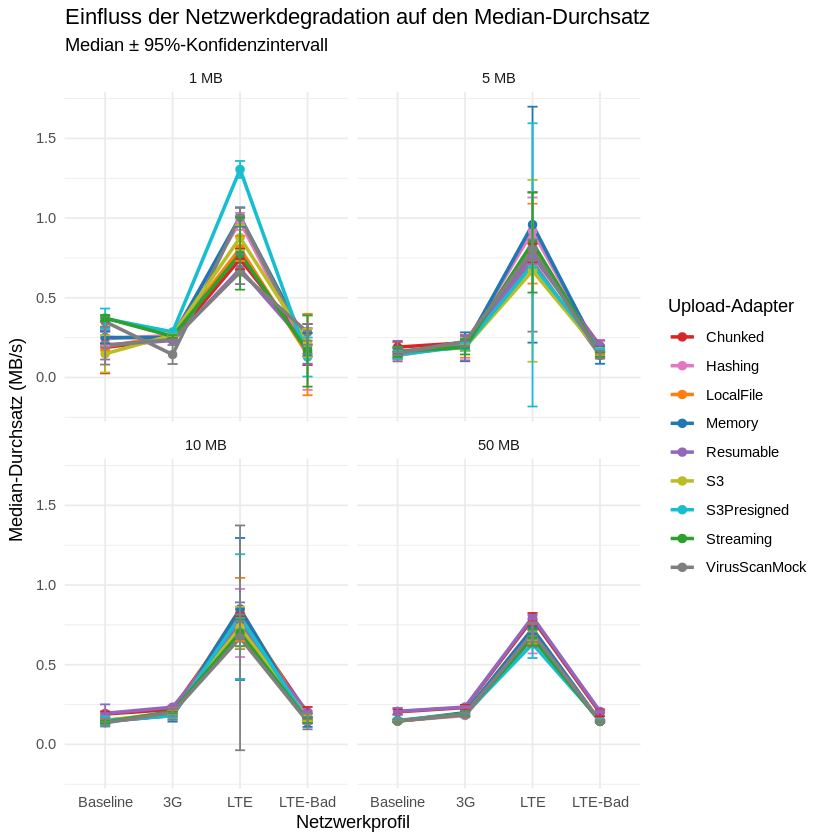

In [173]:
plot_ff2 <- ggplot(
  ff2_plot_data,
  aes(
    x = NetworkPreset,
    y = Median_MBps,
    color = UploadAdapter,
    group = UploadAdapter
  )
) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  geom_errorbar(
    aes(
      ymin = Median_MBps - CI95,
      ymax = Median_MBps + CI95
    ),
    width = 0.15
  ) +
  facet_wrap(~ FileSizeCategory) +
  scale_color_manual(values = adapter_colors) +
  labs(
    title = "Einfluss der Netzwerkdegradation auf den Median-Durchsatz",
    subtitle = "Median \u00b1 95%-Konfidenzintervall",
    x = "Netzwerkprofil",
    y = "Median-Durchsatz (MB/s)",
    color = "Upload-Adapter"
  ) +
  theme_minimal()

  plot_ff2

  save_plot(
    plot_ff2,
    "03-ff2-network-degradation.png",
    width = 12,
    height = 8
  )

  cat("\u2713 Abbildung gespeichert unter:\n")
  cat("../output/figures/03-ff2-network-degradation.png\n")


### FF2 - Automatische Antwort generieren

Die Antwort auf FF2 wird mit den erhobenen Messdaten kombiniert und ausgegeben.

In [189]:
staerkster_adapter <-
  ff2_staerkster_verlust$UploadAdapter

staerkstes_profil <-
  ff2_staerkster_verlust$NetworkPreset

staerkster_verlust <-
  ff2_staerkster_verlust$Performanceverlust_Prozent

stabilster_adapter <-
  ff2_geringster_verlust$UploadAdapter

stabilstes_profil <-
  ff2_geringster_verlust$NetworkPreset

geringster_verlust <-
  ff2_geringster_verlust$Performanceverlust_Prozent

signifikante_adapter <- ff2_tests |>
  dplyr::filter(Signifikant) |>
  dplyr::pull(UploadAdapter)

signifikante_adapter_text <-
  format_liste(signifikante_adapter)

ff2_text <- glue::glue(
"\n# Beantwortung der Forschungsfrage FF2\n\nZur Untersuchung des Einflusses der Netzwerkdegradation wurde der\nMedian-Durchsatz jedes Upload-Adapters mit seinem jeweiligen\nMedian-Durchsatz in der stabilen Referenzumgebung\n**Baseline** verglichen.\n\nDer stärkste relative Performanceverlust wurde für\n**{staerkster_adapter}** im Netzwerkprofil\n**{staerkstes_profil}** festgestellt. Gegenüber der Baseline sank der\nMedian-Durchsatz um\n**{format(round(staerkster_verlust, 2), decimal.mark = ',')} %**.\n\nDen geringsten relativen Performanceverlust zeigte\n**{stabilster_adapter}** im Netzwerkprofil\n**{stabilstes_profil}** mit einer Veränderung von\n**{format(round(geringster_verlust, 2), decimal.mark = ',')} %**.\n\nDie adapterbezogenen Kruskal-Wallis-Tests zeigten nach\nBonferroni-Korrektur für folgende Upload-Adapter signifikante\nUnterschiede zwischen den Netzwerkprofilen:\n\n**{signifikante_adapter_text}**\n\n## Antwort auf FF2\n\nDie Netzwerkdegradation beeinflusst die Performance der Upload-\nStrategien in unterschiedlichem Ausmaß. Maßgeblich ist der relative\nRückgang des Median-Durchsatzes gegenüber der Baseline. Besonders\nstark betroffen war **{staerkster_adapter}**, während\n**{stabilster_adapter}** unter den betrachteten degradierenden\nBedingungen den geringsten relativen Performanceverlust aufwies.\n"
)

IRdisplay::display_markdown(ff2_text)

# FF2-Bericht in Markdown-Datei speichern
writeLines(
  ff2_text,
  file.path(REPORT_DIR, "ff2.md")
)

# Beantwortung der Forschungsfrage FF2

Zur Untersuchung des Einflusses der Netzwerkdegradation wurde der
Median-Durchsatz jedes Upload-Adapters mit seinem jeweiligen
Median-Durchsatz in der stabilen Referenzumgebung
**Baseline** verglichen.

Der stärkste relative Performanceverlust wurde für
**QueueBased** im Netzwerkprofil
**LTE-Bad** festgestellt. Gegenüber der Baseline sank der
Median-Durchsatz um
**4,69 %**.

Den geringsten relativen Performanceverlust zeigte
**Memory** im Netzwerkprofil
**LTE** mit einer Veränderung von
**-455,12 %**.

Die adapterbezogenen Kruskal-Wallis-Tests zeigten nach
Bonferroni-Korrektur für folgende Upload-Adapter signifikante
Unterschiede zwischen den Netzwerkprofilen:

**Chunked, Hashing, LocalFile, Memory, QueueBased, Resumable, S3, S3Presigned, Streaming und VirusScanMock**

## Antwort auf FF2

Die Netzwerkdegradation beeinflusst die Performance der Upload-
Strategien in unterschiedlichem Ausmaß. Maßgeblich ist der relative
Rückgang des Median-Durchsatzes gegenüber der Baseline. Besonders
stark betroffen war **QueueBased**, während
**Memory** unter den betrachteten degradierenden
Bedingungen den geringsten relativen Performanceverlust aufwies.

## 5.3 - Forschungsfrage 3 (FF3)

**Welche praxisrelevanten Empfehlungen lassen sich aus den Ergebnissen für die Auswahl einer Upload-Strategie in Abhängigkeit von Netzwerkprofil und Dateigröße ableiten?**

FF3 wird mit Hilfe einer Entscheidungsmatrix beantwortet, die auf den Ergebnissen von FF1 und FF2 aufbaut.

### FF3 - Ergebnisse aggregieren

Zur Beantwortung von FF3 wurden die Benchmarkdaten zunächst nach Netzwerkprofil, Dateigröße und Upload-Strategie gruppiert. Für jede Kombination wurde der Median-Durchsatz als robuster Lageparameter berechnet. Auf dieser aggregierten Datengrundlage wird anschließend die Upload-Strategie mit dem höchsten Median-Durchsatz ausgewählt, sofern die Erfolgsquote mindestens 90 % beträgt.

Die Aggregation reduziert zufällige Schwankungen einzelner Benchmarkläufe und ermöglicht die Ableitung belastbarer, praxisorientierter Empfehlungen.

In [175]:
ff3_summary <- benchmark_df |>
  group_by(
    NetworkPreset,
    FileSizeCategory,
    UploadAdapter
  ) |>
  summarise(
    Anzahl = n(),
    Median_MBps = median(ThroughputMBs),
    Erfolgsquote = mean(Success) * 100,
    .groups = "drop"
  )

### FF3 - Nur zuverlässige Adapter zulassen

Es sollen nur Adapter mit einer sehr guten Erfolgsquote berücksichtigt werden.

In [176]:
ff3_candidates <- ff3_summary |>
  filter(Erfolgsquote >= 90)

### FF3 - Besten Adapter je Kombination bestimmen

Es genügt nicht, einfach den Adapter mit dem besten Durchsatz zu bestimmen. Die Performance eines Upload-Adapters hängt von den Randbedingungen ab. Ein Adapter kann unter einer stabilen Verbindung hervorragend sein, unter einer schlechten Mobilfunkverbindung aber deutlich schlechter abschneiden.

In [177]:
ff3_matrix <- ff3_candidates |>
  group_by(NetworkPreset, FileSizeCategory) |>
  slice_max(
    Median_MBps,
    n = 1,
    with_ties = FALSE
  ) |>
  ungroup()

### FF3 - Als Matrix darstellen

Zur Beantwortung der Forschungsfrage FF3 wird für jede Kombination aus Dateigröße und Netzwerkprofil der Upload-Adapter mit dem höchsten Median-Durchsatz bei einer Erfolgsquote von mindestens 90 % bestimmt. Die daraus abgeleiteten Empfehlungen werden in Form einer Entscheidungsmatrix übersichtlich dargestellt.

In [178]:
ff3_matrix <- ff3_candidates |>
  group_by(NetworkPreset, FileSizeCategory) |>
  slice_max(
    Median_MBps,
    n = 1,
    with_ties = FALSE
  ) |>
  ungroup()

decision_matrix <- ff3_matrix |>
  select(
    NetworkPreset,
    FileSizeCategory,
    UploadAdapter
  ) |>
  tidyr::pivot_wider(
    names_from = FileSizeCategory,
    values_from = UploadAdapter
  )

knitr::kable(decision_matrix)



|NetworkPreset |1 MB          |5 MB          |10 MB     |50 MB     |
|:-------------|:-------------|:-------------|:---------|:---------|
|3G            |S3Presigned   |VirusScanMock |Resumable |Resumable |
|Baseline      |Streaming     |Chunked       |Resumable |Resumable |
|LTE           |S3Presigned   |Memory        |Memory    |Resumable |
|LTE-Bad       |VirusScanMock |Chunked       |Resumable |Resumable |

### FF3 - Entscheidungsmatrix als Heatmap

Während die Entscheidungsmatrix die empfohlene Upload-Strategie je Kombination aus Netzwerkprofil und Dateigröße zusammenfasst, ermöglicht die ergänzende Heatmap einen schnellen visuellen Vergleich der zugrunde liegenden Median-Durchsätze.

✓ Abbildung gespeichert: content/output/figures/04-decision-matrix-heatmap.png
✓ Abbildung gespeichert unter:
../output/figures/04-decision-matrix-heatmap.png


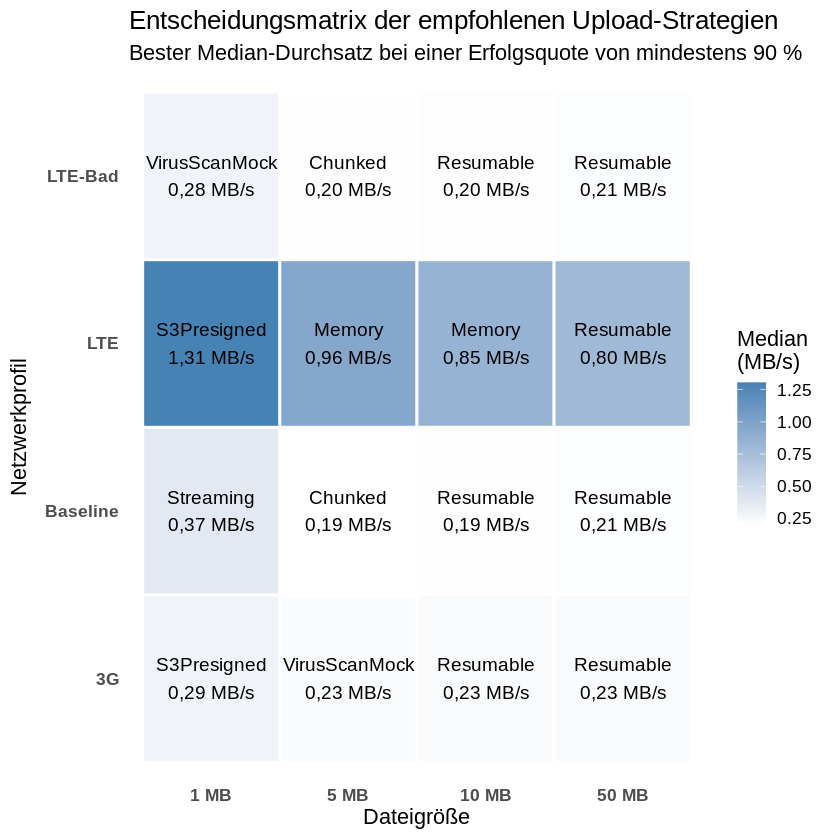

In [179]:
# ---------------------------------------------------------
# Entscheidungsmatrix als Heatmap
# ---------------------------------------------------------

plot_decision_heatmap <- ggplot(
  ff3_matrix,
  aes(
    x = FileSizeCategory,
    y = NetworkPreset,
    fill = Median_MBps
  )
) +
  geom_tile(
    color = "white",
    linewidth = 0.8
  ) +
  geom_text(
    aes(
      label = paste0(
        UploadAdapter,
        "\n",
        format(round(Median_MBps, 2), decimal.mark = ","),
        " MB/s"
      )
    ),
    size = 4
  ) +
  scale_fill_gradient(
    low = "white",
    high = "steelblue"
  ) +
  labs(
    title = "Entscheidungsmatrix der empfohlenen Upload-Strategien",
    subtitle = "Bester Median-Durchsatz bei einer Erfolgsquote von mindestens 90 %",
    x = "Dateigröße",
    y = "Netzwerkprofil",
    fill = "Median\n(MB/s)"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold")
  )

plot_decision_heatmap

# Speichern nicht vergessen
save_plot(
  plot_decision_heatmap,
  "04-decision-matrix-heatmap.png",
  width = 11,
  height = 7
)

cat("✓ Abbildung gespeichert unter:\n")
cat("../output/figures/04-decision-matrix-heatmap.png\n")

### FF3 - Automatische Antwort generieren

Die Antwort auf FF3 wird mit den erhobenen Messdaten kombiniert und ausgegeben.

In [180]:
# Häufigkeit der Empfehlungen je Adapter
ff3_frequency <- ff3_matrix |>
  dplyr::count(UploadAdapter, name = "Anzahl_Empfehlungen") |>
  dplyr::arrange(dplyr::desc(Anzahl_Empfehlungen))

haeufigster_adapter <- ff3_frequency$UploadAdapter[1]
haeufigkeit <- ff3_frequency$Anzahl_Empfehlungen[1]
gesamt_kombinationen <- nrow(ff3_matrix)

grosse_dateien <- ff3_matrix |>
  dplyr::filter(FileSizeCategory == "50 MB") |>
  dplyr::pull(UploadAdapter) |>
  unique()

grosse_dateien_text <- format_liste(grosse_dateien)

In [190]:
ff3_text <- glue::glue(
"\n# Beantwortung der Forschungsfrage FF3\n\nFür jede Kombination aus Netzwerkprofil und Dateigröße wurde der\nUpload-Adapter mit dem höchsten Median-Durchsatz ausgewählt, sofern\nseine Erfolgsquote mindestens 90 % betrug.\n\nDer Adapter **{haeufigster_adapter}** wurde in\n**{haeufigkeit} von {gesamt_kombinationen}** untersuchten Kombinationen\nempfohlen und ist damit die am häufigsten ausgewählte Strategie.\n\nBei Dateien mit **50 MB** wurde in allen betrachteten Netzwerkprofilen\n**{grosse_dateien_text}** empfohlen. Bei kleineren Dateien hängt die\ngeeignete Strategie stärker vom jeweiligen Netzwerkprofil ab.\n\n## Antwort auf FF3\n\nFür große Dateien ist **{grosse_dateien_text}** die stabilste\npraxisorientierte Empfehlung über alle Netzwerkprofile hinweg.\nBei kleinen und mittleren Dateien sollte die Upload-Strategie dagegen\nabhängig vom konkreten Netzwerkprofil gewählt werden. Unter stabilen\nBedingungen werden eher **Streaming** oder **Chunked** empfohlen,\nwährend unter degradierten Bedingungen auch **S3Presigned**,\n**VirusScanMock** und **Memory** je nach Dateigröße die höchste\ngemessene Leistung erreichen.\n"
)

IRdisplay::display_markdown(ff3_text)

# FF3-Bericht in Markdown-Datei speichern
writeLines(
  ff3_text,
  file.path(REPORT_DIR, "ff3.md")
)

# Beantwortung der Forschungsfrage FF3

Für jede Kombination aus Netzwerkprofil und Dateigröße wurde der
Upload-Adapter mit dem höchsten Median-Durchsatz ausgewählt, sofern
seine Erfolgsquote mindestens 90 % betrug.

Der Adapter **Resumable** wurde in
**7 von 16** untersuchten Kombinationen
empfohlen und ist damit die am häufigsten ausgewählte Strategie.

Bei Dateien mit **50 MB** wurde in allen betrachteten Netzwerkprofilen
**Resumable** empfohlen. Bei kleineren Dateien hängt die
geeignete Strategie stärker vom jeweiligen Netzwerkprofil ab.

## Antwort auf FF3

Für große Dateien ist **Resumable** die stabilste
praxisorientierte Empfehlung über alle Netzwerkprofile hinweg.
Bei kleinen und mittleren Dateien sollte die Upload-Strategie dagegen
abhängig vom konkreten Netzwerkprofil gewählt werden. Unter stabilen
Bedingungen werden eher **Streaming** oder **Chunked** empfohlen,
während unter degradierten Bedingungen auch **S3Presigned**,
**VirusScanMock** und **Memory** je nach Dateigröße die höchste
gemessene Leistung erreichen.

# 6 - Zusammenfassung

In der Zusammenfassung wird vor allem die Auswertung der Benchmarkdaten noch einmal zusammengefasst.

In [182]:
gesamt_records <- nrow(benchmark_df)
anzahl_adapter <- length(unique(benchmark_df$UploadAdapter))
anzahl_netzwerke <- length(unique(benchmark_df$NetworkPreset))
anzahl_dateigroessen <- length(unique(benchmark_df$FileSizeCategory))

bester_adapter <- ff1_ranking$UploadAdapter[1]
bester_median <- ff1_ranking$Median_MBps[1]

haeufigster_adapter <- ff3_frequency$UploadAdapter[1]
haeufigkeit <- ff3_frequency$Anzahl_Empfehlungen[1]

In [191]:
executive_summary <- glue::glue(
"\n# Executive Summary\n\nDieser Benchmarkbericht basiert auf **{gesamt_records} BenchmarkRecords**,\ndie **{anzahl_adapter} Upload-Strategien**, **{anzahl_netzwerke}\nNetzwerkprofile** und **{anzahl_dateigroessen} Dateigrößen**\numfassen.\n\nDie deskriptive Statistik sowie die anschließenden\nHypothesentests zeigen, dass sich die Upload-Strategien hinsichtlich\nihrer Leistungsfähigkeit unterscheiden. Der Kruskal-Wallis-Test\nbestätigte statistisch signifikante Unterschiede zwischen den\nUpload-Adaptern, die durch den Dunn-Post-hoc-Test weiter\ndifferenziert wurden.\n\nIm betrachteten Benchmark erzielte **{bester_adapter}**\nmit einem Median-Durchsatz von\n**{format(round(bester_median, 2), decimal.mark = ',')} MB/s**\ndie höchste deskriptive Performance.\n\nAuf Grundlage der Ergebnisse wurde eine automatische\nEntscheidungsmatrix erstellt, welche für jede Kombination aus\nNetzwerkprofil und Dateigröße die geeignete Upload-Strategie\nempfiehlt. **{haeufigster_adapter}** wurde dabei in\n**{haeufigkeit} Entscheidungssituationen** als bevorzugte Strategie\nidentifiziert.\n\nDas Notebook erzeugt sämtliche Tabellen, Diagramme,\nHypothesentests, Forschungsfragen und Handlungsempfehlungen\nvollautomatisch aus den Benchmarkdaten und ermöglicht dadurch eine\nvollständig reproduzierbare wissenschaftliche Auswertung.\n"
)

IRdisplay::display_markdown(executive_summary)

# Executive Summary in Markdown-Datei speichern
writeLines(
  executive_summary,
  file.path(REPORT_DIR, "executive-summary.md")
)

# Gesamtbericht in Markdown-Datei speichern
benchmark_report <- paste(
    report_title,
    executive_summary,
    ff1_text,
    ff2_text,
    ff3_text,
    sep = "\n\n---\n\n"
)

writeLines(
  benchmark_report,
  file.path(REPORT_DIR, "benchmark-report.md")
)

# Executive Summary

Dieser Benchmarkbericht basiert auf **800 BenchmarkRecords**,
die **10 Upload-Strategien**, **4
Netzwerkprofile** und **4 Dateigrößen**
umfassen.

Die deskriptive Statistik sowie die anschließenden
Hypothesentests zeigen, dass sich die Upload-Strategien hinsichtlich
ihrer Leistungsfähigkeit unterscheiden. Der Kruskal-Wallis-Test
bestätigte statistisch signifikante Unterschiede zwischen den
Upload-Adaptern, die durch den Dunn-Post-hoc-Test weiter
differenziert wurden.

Im betrachteten Benchmark erzielte **Resumable**
mit einem Median-Durchsatz von
**0,23 MB/s**
die höchste deskriptive Performance.

Auf Grundlage der Ergebnisse wurde eine automatische
Entscheidungsmatrix erstellt, welche für jede Kombination aus
Netzwerkprofil und Dateigröße die geeignete Upload-Strategie
empfiehlt. **Resumable** wurde dabei in
**7 Entscheidungssituationen** als bevorzugte Strategie
identifiziert.

Das Notebook erzeugt sämtliche Tabellen, Diagramme,
Hypothesentests, Forschungsfragen und Handlungsempfehlungen
vollautomatisch aus den Benchmarkdaten und ermöglicht dadurch eine
vollständig reproduzierbare wissenschaftliche Auswertung.

*Dieser Bericht wurde automatisch durch das MultiPortUpload Benchmark Evaluation Notebook erzeugt.*


In [192]:
cat(
"\n",
"=========================================\n",
" MultiPortUpload Benchmark Evaluation\n",
"=========================================\n",
"\n",
"✓ Benchmark erfolgreich ausgewertet\n",
"✓ Diagramme gespeichert\n",
"✓ Tabellen gespeichert\n",
"✓ Forschungsfragen beantwortet\n",
"✓ Bericht erzeugt\n",
"\n",
sprintf("Bericht: %s\n",
        file.path(REPORT_DIR, "benchmark-report.md")),
"\n",
"=========================================\n"
)


  MultiPortUpload Benchmark Evaluation
 
 ✓ Benchmark erfolgreich ausgewertet
 ✓ Diagramme gespeichert
 ✓ Tabellen gespeichert
 ✓ Forschungsfragen beantwortet
 ✓ Bericht erzeugt
 
 Bericht: content/output/reports/BenchmarkRun.0507.26.FullRun.01/benchmark-report.md
 
